In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
# Scenario 1: Default segment allocation (~90% custom, 2% pre-approved, 8% self-cert, 80% like-for-like)
sim_default = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard"
)
sim = sim_default  # for backward compatibility with other cells

# Get and display statistics
stats = sim_default.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4630 (72.23%)
  CUSTOM_NON_LIKE               : 1148 (17.91%)
  PRE_APPROVED_LIKE             :   93 ( 1.45%)
  PRE_APPROVED_NON_LIKE         :   21 ( 0.33%)
  SELF_CERT_LIKE                :  425 ( 6.63%)
  SELF_CERT_NON_LIKE            :   93 ( 1.45%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     318.13 days
  Median:   303.58 days
  Std Dev:  118.15 days
  Min:       61.70 days
  Max:     1297.81 days

--------------------------------------------------------------------------------
PROCESSING TI

In [2]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 149 (PRE_APPROVED_LIKE): 61.70 days total, 1 re-checks
  Permit 319 (PRE_APPROVED_LIKE): 91.84 days total, 0 re-checks
  Permit 1472 (CUSTOM_LIKE): 92.89 days total, 0 re-checks
  Permit 662 (CUSTOM_LIKE): 96.10 days total, 1 re-checks
  Permit 1650 (CUSTOM_LIKE): 97.28 days total, 0 re-checks


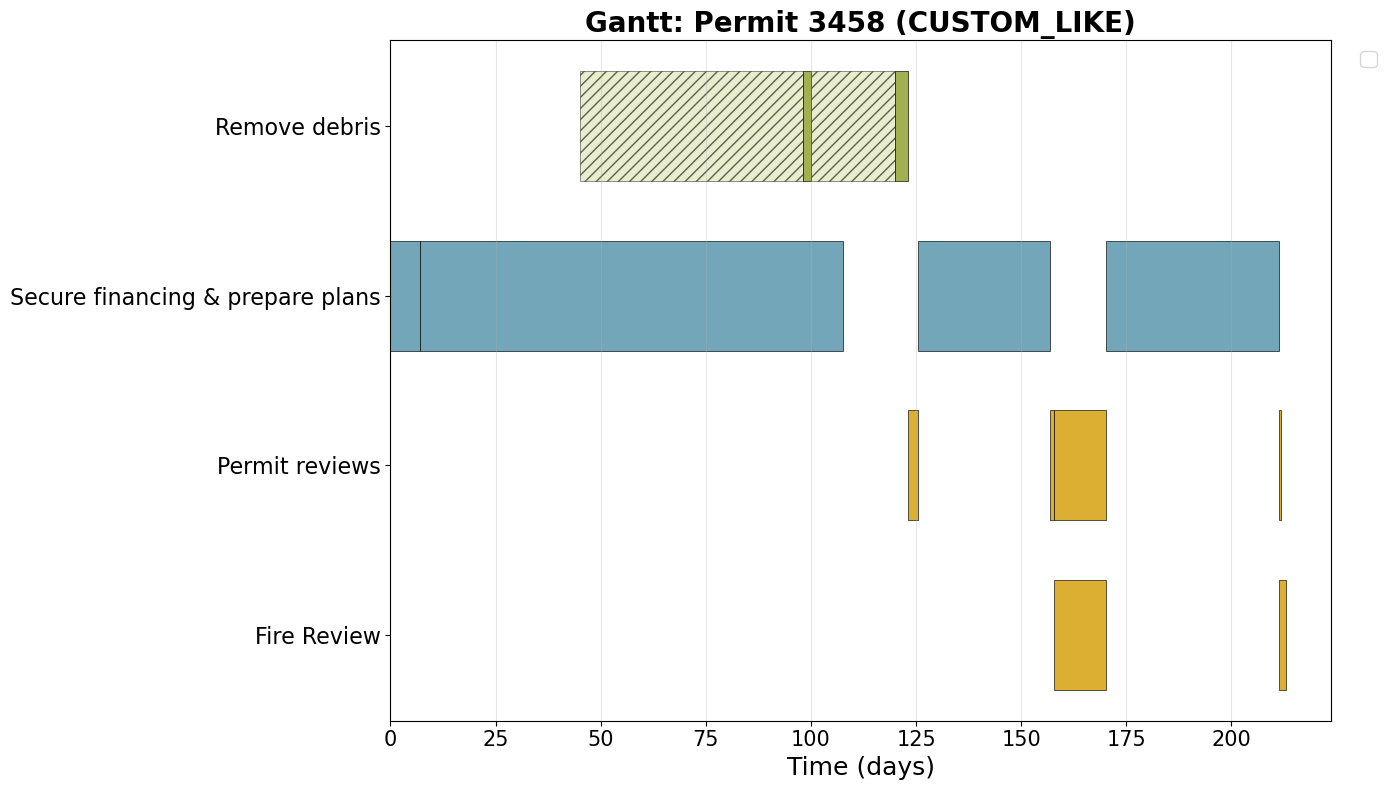

In [3]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt

fig, ax = plot_gantt_single_permit(
    sim.completed_permits[1100],
    figsize=(14, 8), 
)
if fig:
    plt.show()

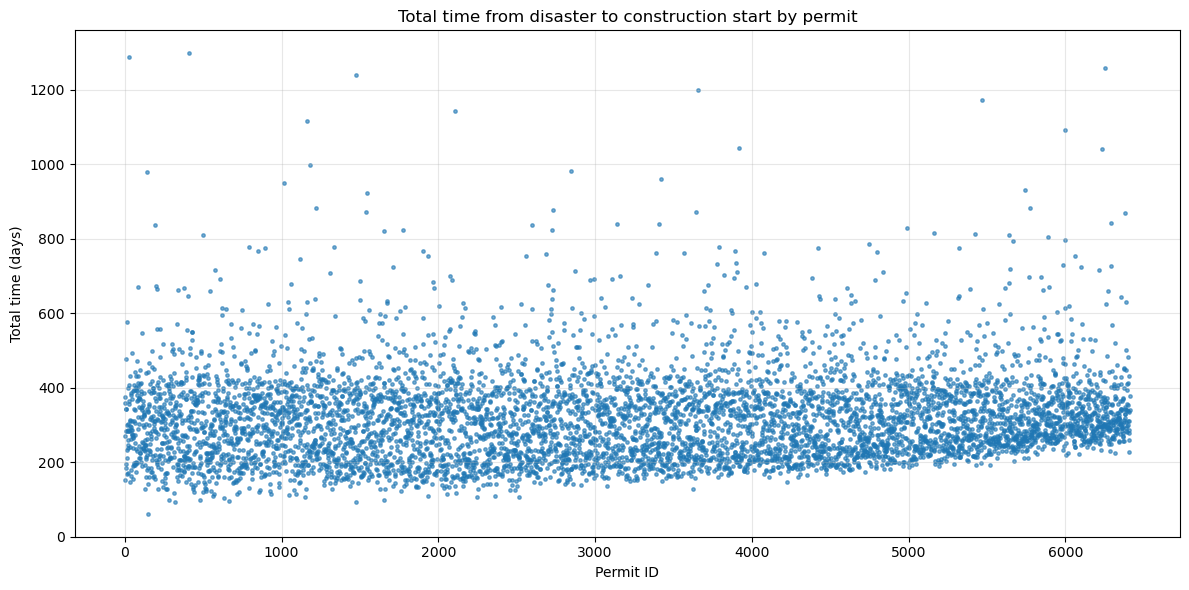

In [4]:
# Plot permit number (ID) vs total time to construction
import matplotlib.pyplot as plt

permit_ids = []
total_times = []

for p in sim.completed_permits:
    if p.ready_for_construction is not None and p.created_at is not None:
        permit_ids.append(p.permit_id)
        total_times.append(p.ready_for_construction - p.created_at)

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, s=6, alpha=0.6)
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

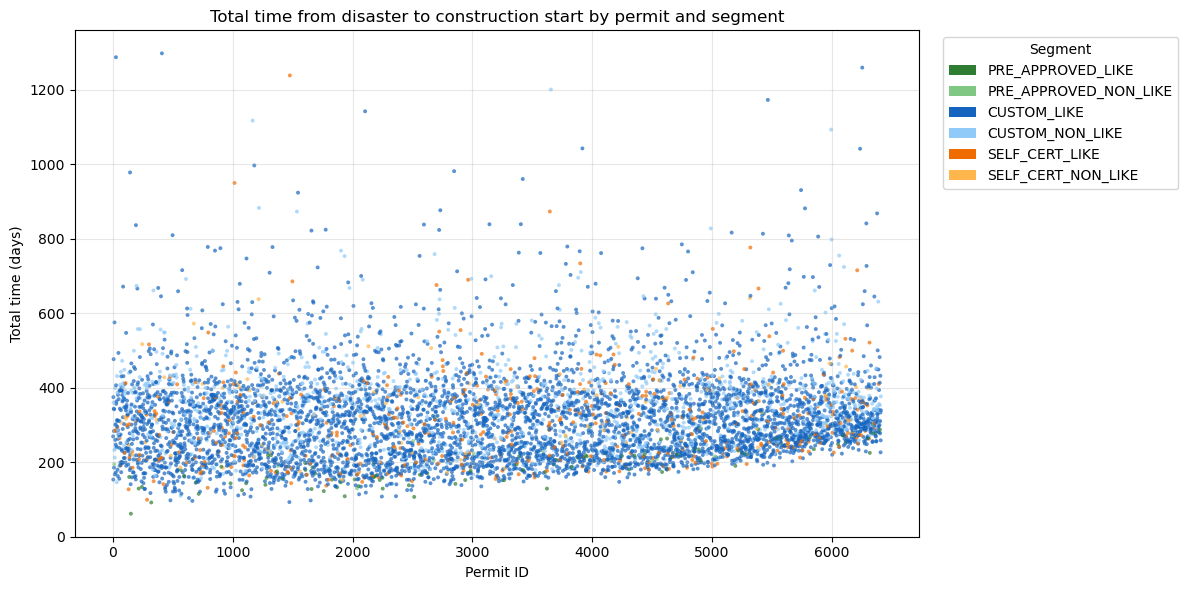

In [5]:
# Scatter plot: permit ID vs total time, colored by segment
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

permit_ids = []
total_times = []
segments = []

for p in sim.completed_permits:
    if p.ready_for_construction is None or p.created_at is None:
        continue
    permit_ids.append(p.permit_id)
    total_times.append(p.ready_for_construction - p.created_at)
    segments.append(p.segment)

# Define a color for each segment
from permit_simulation import Segment
segment_colors = {
    Segment.PRE_APPROVED_LIKE: "#2E7D32",      # green
    Segment.PRE_APPROVED_NON_LIKE: "#81C784",  # light green
    Segment.CUSTOM_LIKE: "#1565C0",            # blue
    Segment.CUSTOM_NON_LIKE: "#90CAF9",        # light blue
    Segment.SELF_CERT_LIKE: "#EF6C00",         # orange
    Segment.SELF_CERT_NON_LIKE: "#FFB74D",     # light orange,
}

colors = [segment_colors.get(seg, "#888888") for seg in segments]

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, c=colors, s=8, alpha=0.7, edgecolors="none")
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit and segment")
plt.grid(alpha=0.3)

# Legend
legend_patches = []
for seg, color in segment_colors.items():
    legend_patches.append(Patch(facecolor=color, edgecolor="none", label=seg.name))
plt.legend(handles=legend_patches, title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

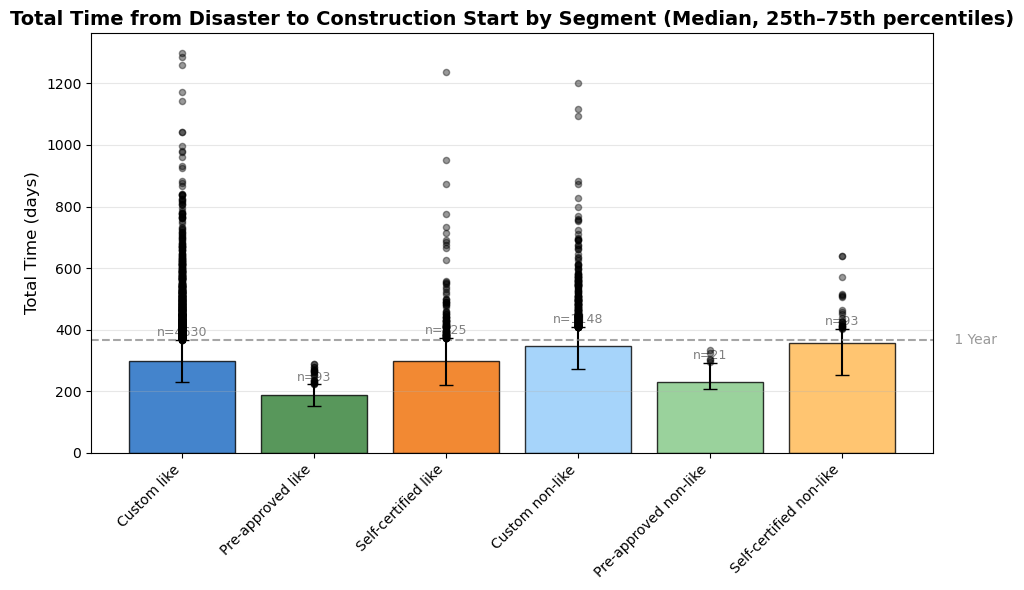

In [6]:
from visualize_permits import plot_total_time_by_segment_quartiles

fig, ax = plot_total_time_by_segment_quartiles(sim.completed_permits)
plt.show()

In [7]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6410
print("Running simulation with " + str(num_permits) + " permits...")
# Scenario 2: Balanced segment allocation (50% pre-approved, 25% custom, 25% self-cert, 80% like-for-like)
sim_balanced = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard",
    pct_pre_approved=0.5,
    pct_custom=0.25,
    pct_self_cert=0.25,
    pct_like_for_like=0.8
)

# Get and display statistics
stats = sim_balanced.get_statistics()
print_statistics(stats)

Running simulation with 6410 permits...

SIMULATION STATISTICS

Total Completed Permits: 6410
Total In Progress: 0

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 1307 (20.39%)
  CUSTOM_NON_LIKE               :  311 ( 4.85%)
  PRE_APPROVED_LIKE             : 2536 (39.56%)
  PRE_APPROVED_NON_LIKE         :  645 (10.06%)
  SELF_CERT_LIKE                : 1305 (20.36%)
  SELF_CERT_NON_LIKE            :  306 ( 4.77%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     272.89 days
  Median:   260.88 days
  Std Dev:  110.29 days
  Min:       57.17 days
  Max:     1306.44 days

--------------------------------------------------------------------------------
PROCESSING TI

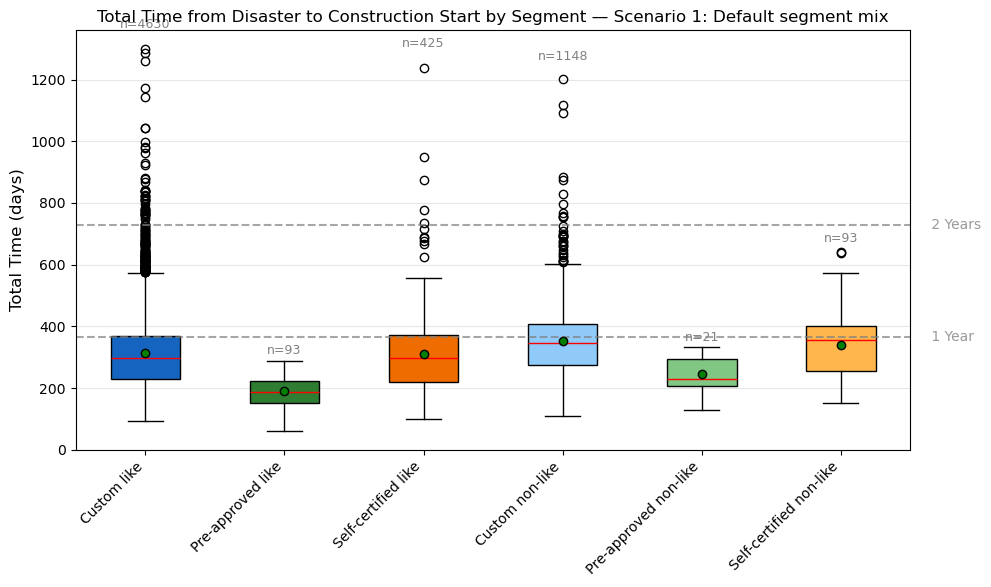

In [8]:
from visualize_permits import plot_total_time_by_segment
import matplotlib.pyplot as plt

# Box-and-whisker: Scenario 1 — Default segment allocation
fig, ax = plot_total_time_by_segment(sim_default.completed_permits, figsize=(10, 6), show_boxplot=True)
if ax is not None:
    ax.set_title("Total Time from Disaster to Construction Start by Segment — Scenario 1: Default segment mix", fontsize=12)
plt.show()

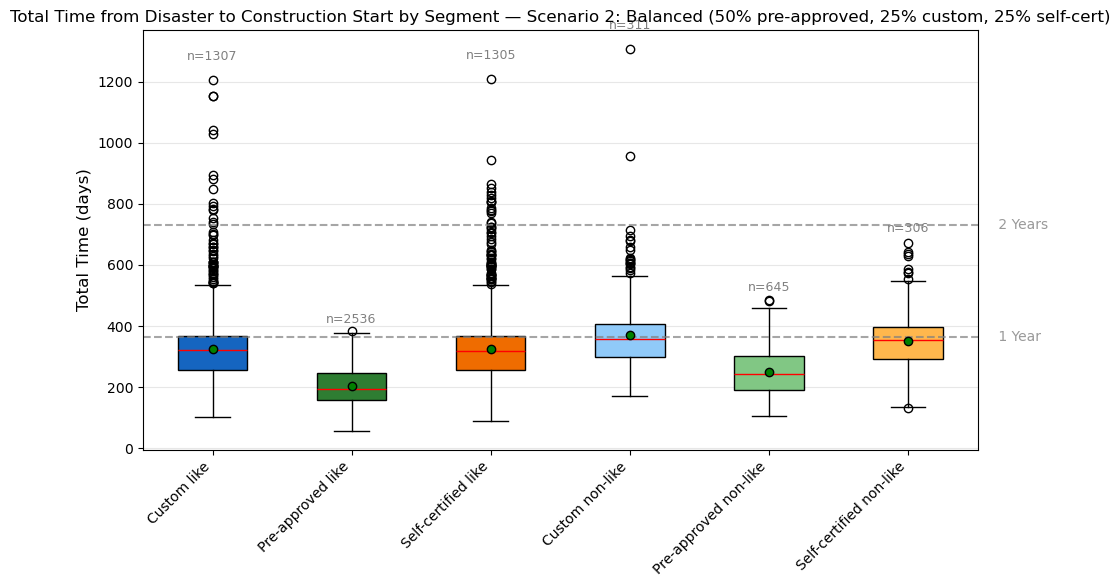

In [9]:
# Box-and-whisker: Scenario 2 — Balanced segment allocation (50% pre-approved, 25% custom, 25% self-cert, 80% like-for-like)
fig, ax = plot_total_time_by_segment(sim_balanced.completed_permits, figsize=(10, 6), show_boxplot=True)
if ax is not None:
    ax.set_title("Total Time from Disaster to Construction Start by Segment — Scenario 2: Balanced (50% pre-approved, 25% custom, 25% self-cert)", fontsize=12)
plt.show()